In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import spacy
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
nlp = spacy.load("es_core_news_sm")



# Ejercicio 1

Ejercicio 1 - RNN
Se propone entrenar modelos simples de redes neuronales recurrentes (RNN por sus
siglas en inglés) sobre un conjunto de noticias clasificadas como verdaderas o falsas
(fake news).
Para ello, se utilizará el ficherto train.xlsx del conjunto de datos The Spanish Fake News
Corpus, visto en ejercicios anteriores. Puedes obtener de nuevo dicho fichero a través
del siguiente enlace:
https://github.com/jpposadas/FakeNewsCorpusSpanish/tree/master

## 1.1 Carga dataset

Carga del dataset - Descarga el anterior dataset y obtén los títulos de las noticias
(columna Headline), el contenido de estas (columna Text) y sus etiquetas (columna
Category). Clasifica las etiquetas en 0 si la noticia es real (True) y 1 si es falsa (Fake)

In [2]:
!pip install openpyxl

In [3]:
df = pd.read_excel(r'/mnt/c/Users/carme/Desktop/PLN/T4_listados/Tema4Hoja2/train.xlsx')

print(df.head())

   Id Category      Topic          Source  \
0   1     Fake  Education  El Ruinaversal   
1   2     Fake  Education     Hay noticia   
2   3     Fake  Education  El Ruinaversal   
3   4     True  Education    EL UNIVERSAL   
4   5     Fake  Education          Lamula   

                                            Headline  \
0  RAE INCLUIRÁ LA PALABRA "LADY" EN EL DICCIONAR...   
1            La palabra "haiga", aceptada por la RAE   
2  YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...   
3  UNAM capacitará a maestros para aprobar prueba...   
4  pretenden aprobar libros escolares con conteni...   

                                                Text  \
0  RAE INCLUIRÁ LA PALABRA "LADY" EN EL DICCIONAR...   
1  La palabra "haiga", aceptada por la RAE La Rea...   
2  YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...   
3  UNAM capacitará a maestros para aprobar prueba...   
4  Alerta: pretenden aprobar libros escolares con...   

                                                Link  


In [4]:
df_x= df[['Headline', 'Text']].copy()

df_y=df['Category'].map({'True': 1, 'Fake': 0}).copy()


## 1.2 Análisis exploratorio

Analiza la distribución del número de palabras tanto en los
títulos de las noticias (frases cortas) como en su contenido (varias frases). Este
análisis será utilizado posteriormente para decidir el tamaño máximo a introducir
por cada documento.

Media títulos  11.372781065088757
Maximo títulos 23
Media contenido  377.8594674556213
Maximo contenido 2081


(array([  3.,  19.,  70., 116., 155., 200.,  57.,  35.,  15.,   6.]),
 array([ 1. ,  3.2,  5.4,  7.6,  9.8, 12. , 14.2, 16.4, 18.6, 20.8, 23. ]),
 <BarContainer object of 10 artists>)

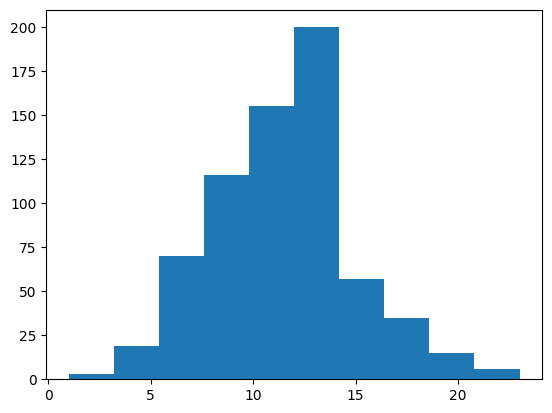

In [5]:

titulos= df['Headline']
contenido= df['Text']
titulos_lengths=[]
contenido_lengths=[]

for t in titulos:
    titulos_lengths.append(len(t.split()))
for c in contenido:
    contenido_lengths.append(len(c.split()))

titulos_lengths=np.array(titulos_lengths)
contenido_lengths=np.array(contenido_lengths)
print("Media títulos ", np.mean(titulos_lengths))
print("Maximo títulos", np.max(titulos_lengths))

print("Media contenido ", np.mean(contenido_lengths))
print("Maximo contenido", np.max(contenido_lengths))

plt.hist(titulos_lengths)



(array([177., 298., 135.,  34.,  14.,   4.,   8.,   1.,   2.,   3.]),
 array([  20. ,  226.1,  432.2,  638.3,  844.4, 1050.5, 1256.6, 1462.7,
        1668.8, 1874.9, 2081. ]),
 <BarContainer object of 10 artists>)

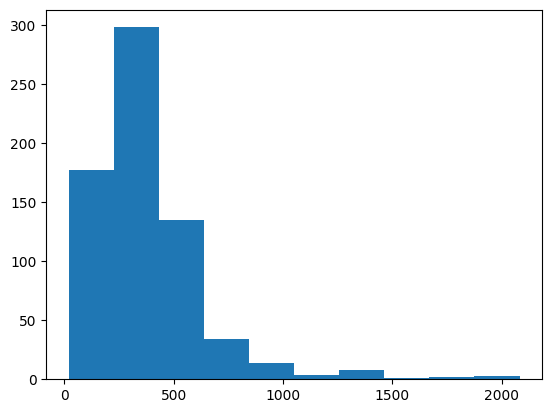

In [6]:
plt.hist(contenido_lengths)

## 1.3 Separación del dataset

Divide los títulos de las noticias y su contenido en sus
correspondientes conjuntos de entrenamiento, validación y test. Recuerda que los
conjuntos de entrenamiento serán usados posteriormente tanto para la
construcción de los vocabularios como para el entrenamiento de las redes
neuronales.

In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test= train_test_split(df_x, df_y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

In [7]:
X_train['Headline']

530    AMLO: Quién tenga dos propiedades o más, solo ...
202           La ONU prohíbe fumar en la guerra de Siria
578    Televisa graba novela con personajes inspirado...
641    Fernando Colunga reaparece tras un largo perio...
394    La felicitación de Trump a la astronauta que l...
                             ...                        
127    Abren sitio web con información de espacios en...
95     La Iglesia prohíbe mantener relaciones durante...
572    Margarita Zavala renuncia a la candidatura pre...
170    Asesinan a Esposa de "El Chapo": PGR asegura q...
610    El jefe de Marvel Comics admite que el camino ...
Name: Headline, Length: 432, dtype: object

## 1.4 Construcción del vocabulario


Construye los vocabularios tanto para los títulos de
las noticias como para su contenido. Realiza un preprocesamiento básico de las
palabras que los componen.

In [8]:
nlp=spacy.load("es_core_news_sm")

def preprocess(text):
    doc=nlp(str(text))
    text_processed=[]
    for t in doc:
        if t.is_alpha and not t.is_stop:
            text_processed.append((t.text).lower())

    return text_processed


def prepare_vocabulary(texts, vocab_size):
    token_to_id={}
    id=1
    for text in texts:
        for token in text:
            if token not in token_to_id and id < vocab_size:
                token_to_id[token]=id
                id+=1
    
    return token_to_id

preprocessed__train_headlines= [preprocess(text) for text in X_train['Headline']]
preprocessed__train_texts= [preprocess(text) for text in X_train['Text']]

voc_headline= prepare_vocabulary(preprocessed__train_headlines, 1000)
voc_text=prepare_vocabulary(preprocessed__train_texts,1000)

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

#Manual
def text_codification(texts, voc, max_length):
    codificated_texts= np.zeros((len(texts), max_length), dtype=int)
    for i, text in enumerate(texts):
        for j, word in enumerate(text):
            if j >= max_length:
                break  # no metemos más de max_length palabras

            id= voc.get(word,0)

            codificated_texts[i][j]=id
    return codificated_texts

#Con pad_sequences

def text_codification_ps(texts, voc, max_length):
    codificated_texts=[]
    for text in texts:
        t=[]
        for word in text:
            id= voc.get(word, 0)
            t.append(id)
        codificated_texts.append(t)

    pad_codificated_text= pad_sequences(codificated_texts,  maxlen=max_length, padding='post', truncating='post')
    return pad_codificated_text



2025-07-02 12:58:21.946464: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-02 12:58:21.969903: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-02 12:58:22.147768: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-02 12:58:22.318871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751453902.471575    1014 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751453902.51

## 1.5. Codificación de textos

Construye las matrices de documentos-términos, donde
cada palabra es representada por su índice en el vocabulario correspondiente. Para
la elección del tamaño máximo, usa el análisis anteriormente realizado sobre la
distribución del número de palabras.

In [59]:
#15 y 500 de tamaño máximo
max_length_hl=15
max_length_t=500
#Construimos la matriz de documentos-términos de train
hl_train_doc_term_matrix= text_codification_ps(preprocessed__train_headlines, voc_headline, 15)
t_train_doc_term_matrix= text_codification_ps(preprocessed__train_texts, voc_text, 500)

#Preprocesamos val y test
preprocessed_val_headlines= [preprocess(text) for text in X_val['Headline']]
preprocessed_val_texts= [preprocess(text) for text in X_val['Text']]

preprocessed_test_headlines= [preprocess(text) for text in X_test['Headline']]
preprocessed_test_texts= [preprocess(text) for text in X_test['Text']]

#Obtenemos matriz de documentos-términos de  val y test
hl_test_doc_term_matrix= text_codification_ps(preprocessed_test_headlines, voc_headline, 15)
t_test_doc_term_matrix= text_codification_ps(preprocessed_test_texts, voc_text, 500)

hl_val_doc_term_matrix= text_codification_ps(preprocessed_val_headlines, voc_headline, 15)
t_val_doc_term_matrix= text_codification_ps(preprocessed_val_texts, voc_text, 500)


## 1.6 Entrenamiento sobre los títulos
Empleando  la  capa  SimpleRNN()  de  Keras,  diseña  y  entrena  una  red  neuronal 
recurrente  para  los  títulos  de  las  noticias.  Entrena  la  capa  de  embeddings  desde 
cero. Usa los correspondientes conjuntos de validación anteriormente creados para 
evaluar cómo se van entrenando los modelos diseñados.  

b. Prueba distintas configuraciones de la red neuronal (número de neuronas, número 
de dimensiones de la capa de Embeddings, Dropout / Recurrent Dropout...). 

c. Con  los  modelos  entrenados  sobre  los  títulos  de  las  noticias,  realiza  predicciones 
sobre su correspondiente conjunto de test y analiza los resultados obtenidos.

In [ ]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Embedding, Dense
from keras.layers import Dropout


embedding_dim=100
hl_model= Sequential()
hl_model.add(Embedding(input_dim=len(voc_text)+1, 
                       output_dim=embedding_dim, ))
                       #input_length=max_length_hl)) 
# token es un vector: n_docs x max_length x embedding_dim

hl_model.add(SimpleRNN(units=64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))
hl_model.add(SimpleRNN(units=32))  # esta devuelve solo el último estado

hl_model.add(Dense(1, activation='sigmoid'))



#Compilar 

hl_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hl_model.build(input_shape=(None, max_length_hl))
hl_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 15, 100)        │       100,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 15, 64)         │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,697 (444.13 KB)

 Trainable params: 113,697 (444.13 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#Entrenamiento
batch_size=32
epochs=5
history= hl_model.fit(hl_train_doc_term_matrix, y_train, 
             validation_data=(hl_val_doc_term_matrix, y_val),
               batch_size=batch_size, 
               epochs=epochs)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5908 - loss: 0.7085 - val_accuracy: 0.5000 - val_loss: 0.7086
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5173 - loss: 0.7253 - val_accuracy: 0.4815 - val_loss: 0.7062
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5759 - loss: 0.6830 - val_accuracy: 0.4907 - val_loss: 0.7116
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5077 - loss: 0.7138 - val_accuracy: 0.4630 - val_loss: 0.7192
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5965 - loss: 0.6793 - val_accuracy: 0.5463 - val_loss: 0.6955


In [ ]:

y_pred_prob = hl_model.predict(hl_test_doc_term_matrix)
y_pred = (y_pred_prob > 0.5).astype(int)

loss, accuracy = hl_model.evaluate(hl_test_doc_term_matrix, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5133 - loss: 0.7053 


## 1. 7 Entrenamiento sobre los contenidos 
--- Lo saltamos porque sería igual ---

## 1.8 Entrenamiento con embeddings de Word2Vec
 
a. En vez de entrenar los embeddings desde cero, emplea un modelo de Word2Vec en 
español para su inicialización. Puedes usar el modelo “SBW-vectors-300-min5.txt” 
visto en ejercicios anteriores 
(https://www.kaggle.com/datasets/rtatman/pretrained-word-vectors-for-
spanish). 
b. Inicializa los embeddings de las redes neuronales diseñadas anteriormente usando 
Word2Vec.  Prueba  distintas  configuraciones  de  redes  neuronales  y  analiza  los 
resultados obtenidos. 
 


In [ ]:
import numpy as np

def load_word2vec(filepath):
    embeddings_index = {}
    with open(filepath, 'r', encoding='utf8') as f:
        # Algunas versiones comienzan con una línea de cabecera; si fuese tu caso usa `next(f)` para saltarla.
        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
    return embeddings_index

embeddings_index = load_word2vec('/mnt/c/Users/carme/Desktop/PLN/pretrained_word_vectors_spanish/SBW-vectors-300-min5.txt')
print(f"Vocabulario Word2Vec: {len(embeddings_index)} palabras")


Vocabulario Word2Vec: 1000654 palabras


A continuación vamos a obtener los embeddings preentrrenados:

In [ ]:
w2v_model= embeddings_index

embedding_dim=300

#Rellenamos con los vectores preentrenados

def obtener_embedding_w2v(model, embedding_dim, voc):
    embedding_matrix= np.zeros((len(voc)+1, embedding_dim))
    for w in voc:
        if w in model: #nos aseguramos que la palabra está en el embedding
            id= voc[w]
            embedding_matrix[id]= model[w]
        
    return embedding_matrix
                               

In [41]:
#Esto se mantendría igual para el caso de usar embeddings preentrenados, la diferencia es a la hora de crear la capa en el modelo
"""
hl_train_doc_term_matrix= text_codification_ps(preprocessed__train_headlines, voc_headline, 15)
hl_test_doc_term_matrix= text_codification_ps(preprocessed_test_headlines, voc_headline, 15)
hl_val_doc_term_matrix= text_codification_ps(preprocessed_val_headlines, voc_headline, 15)
""" 
embedding_matrix= obtener_embedding_w2v(w2v_model, embedding_dim, voc_headline)

In [ ]:
from keras.layers import LSTM, Bidirectional

hl_model2= Sequential()

hl_model2.add(Embedding(input_dim=(len(voc_headline)+1), output_dim=300 # la que sea el modelo
                        , weights= [embedding_matrix], 
                        trainable= False))
hl_model2.add(Bidirectional(LSTM(units=64, dropout=0.3, recurrent_dropout=0.3)))

hl_model2.add(Dense(1, activation='sigmoid'))

In [56]:
hl_model2.compile(optimizer='adam', loss="binary_crossentropy", metrics=['accuracy'])
hl_model2.build(input_shape=(None, embedding_dim))
hl_model2.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 300, 300)       │       300,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,009 (1.86 MB)

 Trainable params: 187,009 (730.50 KB)

 Non-trainable params: 300,000 (1.14 MB)

# Entrenamiento textos

In [77]:
from keras.layers import LSTM, Bidirectional, Dropout
t_model2= Sequential()

t_model2.add(Embedding(input_dim=(len(voc_text)+1), output_dim=300 # la que sea el modelo
                        , weights= [embedding_matrix], 
                        trainable= False))
t_model2.add(Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.2)))
t_model2.add(Dropout(0.4))
t_model2.add(Bidirectional(LSTM(units=32, recurrent_dropout=0.2)))
t_model2.add(Dropout(0.4))
t_model2.add(Dense(50, activation='relu'))
t_model2.add(Dense(1, activation='sigmoid'))

In [78]:
t_model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [79]:
t_model2.build(input_shape=(None, embedding_dim))

In [80]:
t_model2.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_24 (Embedding)        │ (None, 300, 300)       │       300,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 300, 128)       │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,397 (2.03 MB)

 Trainable params: 231,397 (903.89 KB)

 Non-trainable params: 300,000 (1.14 MB)

In [81]:
batch_size=32
epochs=5

history= t_model2.fit(t_train_doc_term_matrix, y_train, validation_data=(t_val_doc_term_matrix, y_val), batch_size=batch_size, epochs=epochs)


Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 985ms/step - accuracy: 0.4916 - loss: 0.6937 - val_accuracy: 0.5556 - val_loss: 0.6921
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 923ms/step - accuracy: 0.5003 - loss: 0.6925 - val_accuracy: 0.5278 - val_loss: 0.6923
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 910ms/step - accuracy: 0.5274 - loss: 0.6912 - val_accuracy: 0.6111 - val_loss: 0.6893
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 883ms/step - accuracy: 0.5325 - loss: 0.6894 - val_accuracy: 0.4907 - val_loss: 0.6884
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 894ms/step - accuracy: 0.5480 - loss: 0.6874 - val_accuracy: 0.4815 - val_loss: 0.6885


In [82]:
loss, accuracy= t_model2.evaluate(t_test_doc_term_matrix, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.5490 - loss: 0.6827
